In [1]:
import numpy as np
from sens_elastic import Cantilever as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.3
sens = Sens()
x = np.full(sens.n1*sens.n2, V_MAX)
r = 2.0
eta = 0.5
beta0 = 1
opt = Optimizer(x, 1)
def volume_constraint(x):
    g = np.array([x.sum()/len(x)-V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
fil = Projection(sens.n1, sens.n2, r, eta, beta0)
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x)
    m_nd = fil.grayscale_indicator(x_proj)
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj)
    gradg = fil.modify_sensitivity_gradgi(gradg_proj)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.70e+03, g = -1.36e-02, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 1.18e+03, g = -3.55e-03, norm_inf_x = 5.0e-02, m_nd = 82.70
2 iters, f = 9.53e+02, g = -2.75e-03, norm_inf_x = 5.0e-02, m_nd = 81.66
3 iters, f = 7.98e+02, g = -2.09e-03, norm_inf_x = 5.0e-02, m_nd = 80.08
4 iters, f = 6.80e+02, g = -1.84e-03, norm_inf_x = 5.0e-02, m_nd = 77.96
5 iters, f = 5.84e+02, g = -1.65e-03, norm_inf_x = 5.0e-02, m_nd = 75.20
6 iters, f = 5.05e+02, g = -1.49e-03, norm_inf_x = 5.0e-02, m_nd = 72.05
7 iters, f = 4.51e+02, g = -1.30e-03, norm_inf_x = 5.0e-02, m_nd = 69.35
8 iters, f = 4.05e+02, g = -1.14e-03, norm_inf_x = 5.0e-02, m_nd = 66.76
9 iters, f = 3.66e+02, g = -1.07e-03, norm_inf_x = 5.0e-02, m_nd = 64.17
10 iters, f = 3.31e+02, g = -1.00e-03, norm_inf_x = 5.0e-02, m_nd = 61.33
11 iters, f = 2.99e+02, g = -9.77e-04, norm_inf_x = 5.0e-02, m_nd = 58.55
12 iters, f = 2.71e+02, g = -9.75e-04, norm_inf_x = 5.0e-02, m_nd = 55.39
13 iters, f = 2.45e+02, g = -9.58e-04, norm_inf_

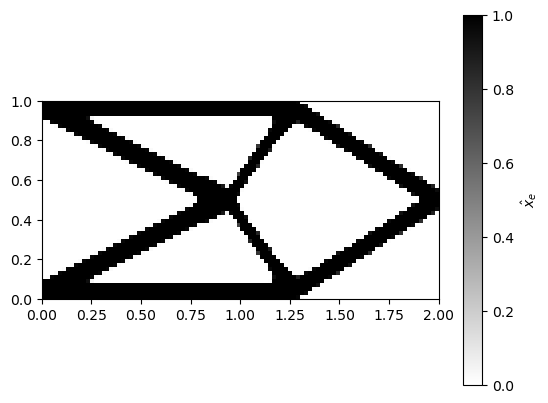

In [2]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
plt.imshow(x_proj.reshape((sens.n2, sens.n1)), origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_p.min(), y_p.max()])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_e$')

In [4]:
def plot_deformation(sens, x_proj, d, scale=1.0):
    X = np.linspace(0, sens.L1, sens.nnx)
    Y = np.linspace(0, sens.L2, sens.nny)
    X, Y = np.meshgrid(X, Y)
    ux = d[0::2].reshape(sens.nny, sens.nnx)
    uy = d[1::2].reshape(sens.nny, sens.nnx)
    Xd, Yd = X + scale*ux, Y + scale*uy 
    C = x_proj.reshape(sens.n2, sens.n1)
    plt.pcolormesh(Xd, Yd, C, shading='flat', cmap='binary', vmin=0.0, vmax=1.0) 
    for j in range(sens.nny): plt.plot(Xd[j,:], Yd[j,:], linewidth=0.5, color='black')
    for i in range(sens.nnx): plt.plot(Xd[:,i], Yd[:,i], linewidth=0.5, color='black')
    plt.gca().set_aspect('equal', 'box')

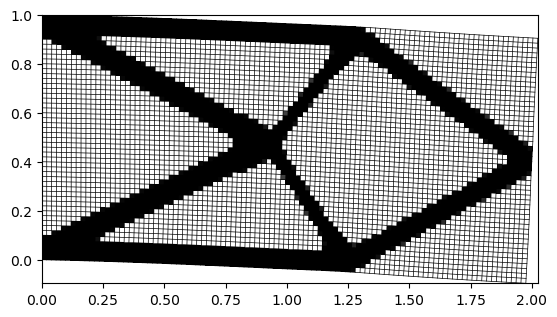

In [4]:
plot_deformation(sens, x_proj, sens.d, scale=0.001)

In [1]:
import numpy as np
from sens_elastic import MBB as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.5
sens = Sens()
x = np.full(sens.n1*sens.n2, V_MAX)
r = 2.0
eta = 0.5
beta0 = 1
opt = Optimizer(x, 1)
def volume_constraint(x):
    g = np.array([x.sum()/len(x)-V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
fil = Projection(sens.n1, sens.n2, r, eta, beta0)
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x)
    m_nd = fil.grayscale_indicator(x_proj)
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj)
    gradg = fil.modify_sensitivity_gradgi(gradg_proj)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.03e+03, g = 0.00e+00, norm_inf_x = 5.0e-02, m_nd = 100.00
1 iters, f = 8.26e+02, g = -4.73e-03, norm_inf_x = 5.0e-02, m_nd = 99.00
2 iters, f = 6.86e+02, g = -4.18e-03, norm_inf_x = 5.0e-02, m_nd = 96.42
3 iters, f = 5.91e+02, g = -2.79e-03, norm_inf_x = 5.0e-02, m_nd = 93.42
4 iters, f = 5.25e+02, g = -2.28e-03, norm_inf_x = 5.0e-02, m_nd = 90.25
5 iters, f = 4.72e+02, g = -2.04e-03, norm_inf_x = 5.0e-02, m_nd = 87.03
6 iters, f = 4.29e+02, g = -1.79e-03, norm_inf_x = 5.0e-02, m_nd = 83.57
7 iters, f = 3.92e+02, g = -1.54e-03, norm_inf_x = 5.0e-02, m_nd = 79.82
8 iters, f = 3.61e+02, g = -1.35e-03, norm_inf_x = 5.0e-02, m_nd = 75.82
9 iters, f = 3.32e+02, g = -1.24e-03, norm_inf_x = 5.0e-02, m_nd = 71.43
10 iters, f = 3.07e+02, g = -1.12e-03, norm_inf_x = 5.0e-02, m_nd = 66.86
11 iters, f = 2.97e+02, g = -8.46e-04, norm_inf_x = 5.0e-02, m_nd = 65.52
12 iters, f = 2.87e+02, g = -7.30e-04, norm_inf_x = 5.0e-02, m_nd = 63.46
13 iters, f = 2.79e+02, g = -7.26e-04, norm_inf_

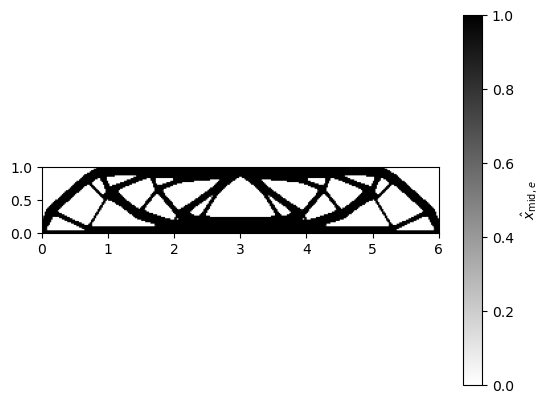

In [2]:
import matplotlib.pyplot as plt
x_proj_full = np.hstack([np.flip(x_proj.reshape((sens.n2, sens.n1)), axis=1), x_proj.reshape((sens.n2, sens.n1))])
plt.imshow(x_proj_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[0, 2*sens.L1, 0, sens.L2])
plt.gca().set_aspect('equal')
plt.colorbar(label=r'$\hat{x}_{\mathrm{mid},e}$')

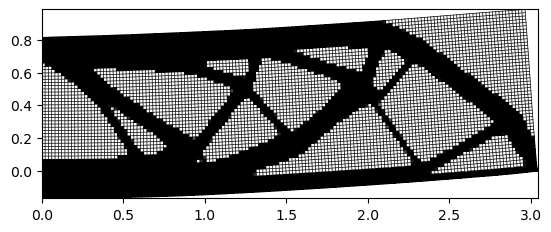

In [6]:
plot_deformation(sens, x_proj, sens.d, scale=0.001)

In [7]:
import numpy as np
from sens_elastic_compmech import Invertor as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.3
sens = Sens()
x = np.full(sens.n1*sens.n2, V_MAX)
r = 2.0
eta = 0.5
beta0 = 1
opt = Optimizer(x, 1)
def volume_constraint(x):
    g = np.array([x.sum()/len(x)-V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
fil = Projection(sens.n1, sens.n2, r, eta, beta0)
for itr in range(ITR_MAX+1):
    x_proj = fil.apply(itr, x)
    m_nd = fil.grayscale_indicator(x_proj)
    f, gradf_proj = sens.compute_obj_sens(x_proj)
    g, gradg_proj = volume_constraint(x_proj)
    gradf = fil.modify_sensitivity_gradf(gradf_proj)
    gradg = fil.modify_sensitivity_gradgi(gradg_proj)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x, np.inf)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 8.90e-02, g = -1.36e-02, norm_inf_x = 5.0e-02, m_nd = 81.76
1 iters, f = 3.28e-02, g = -2.53e-02, norm_inf_x = 5.0e-02, m_nd = 79.04
2 iters, f = 7.76e-03, g = -2.85e-02, norm_inf_x = 5.0e-02, m_nd = 76.76
3 iters, f = 9.69e-04, g = -2.99e-02, norm_inf_x = 5.0e-02, m_nd = 74.49
4 iters, f = 2.72e-05, g = -3.42e-02, norm_inf_x = 4.9e-02, m_nd = 72.22
5 iters, f = -2.85e-06, g = -3.64e-02, norm_inf_x = 4.8e-02, m_nd = 71.36
6 iters, f = -7.77e-05, g = -3.65e-02, norm_inf_x = 5.0e-02, m_nd = 71.29
7 iters, f = -1.72e-03, g = -3.96e-02, norm_inf_x = 5.0e-02, m_nd = 70.05
8 iters, f = -1.09e-02, g = -4.40e-02, norm_inf_x = 5.0e-02, m_nd = 67.58
9 iters, f = -2.80e-02, g = -4.09e-02, norm_inf_x = 5.0e-02, m_nd = 66.31
10 iters, f = -5.47e-02, g = -3.02e-02, norm_inf_x = 5.0e-02, m_nd = 65.83
11 iters, f = -9.04e-02, g = -1.49e-02, norm_inf_x = 5.0e-02, m_nd = 65.29
12 iters, f = -1.34e-01, g = -1.17e-03, norm_inf_x = 5.0e-02, m_nd = 63.86
13 iters, f = -1.81e-01, g = -1.03e-03, 

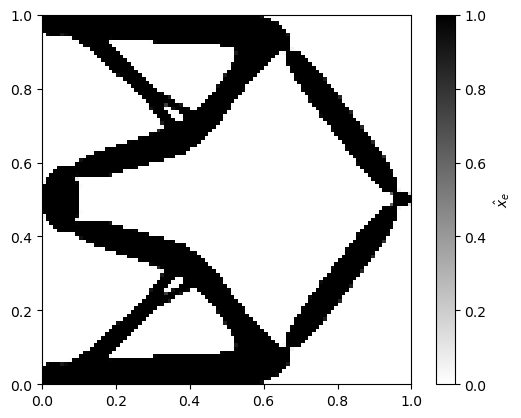

In [8]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
x_proj_reshaped = x_proj.reshape(sens.n2, sens.n1)
x_proj_full = np.vstack([x_proj_reshaped, np.flip(x_proj_reshaped, axis=0)])
y_min = 0.5 - sens.L2
y_max = 0.5 + sens.L2
plt.imshow(x_proj_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_min, y_max])
plt.colorbar(label='$\hat{x}_e$')
plt.gca().set_aspect('equal')

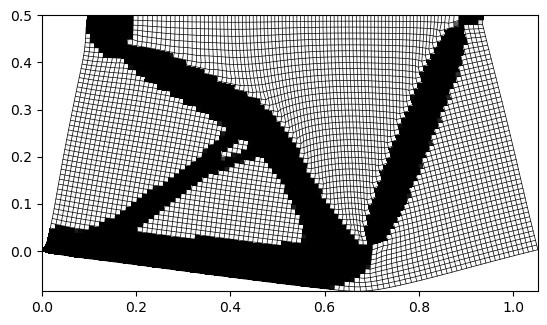

In [9]:
plot_deformation(sens, x_proj, sens.d, scale=0.1)

In [10]:
import numpy as np
from sens_elastic_compmech import Invertor as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.3
sens = Sens()
x = np.full(sens.n1*sens.n2, V_MAX)
r = 2.0
eta0 = 0.25
eta_dil = eta0
eta_mid = 0.5
eta_ero = 1-eta0
beta0 = 1
opt = Optimizer(x, 1) 
def volume_constraint(x):
    g = np.array([x.sum()/len(x)-V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]]
fil_dil, fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters]
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx])
    g, gradg_proj = volume_constraint(x_mid)
    gradf = fil_ero.modify_sensitivity_gradf(gradf_proj)
    gradg = fil_mid.modify_sensitivity_gradgi(gradg_proj)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x_mid, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.28e-01, g = -1.36e-02, norm_inf_x = 6.4e-02, m_nd = 81.76
1 iters, f = 5.23e-02, g = -2.43e-02, norm_inf_x = 6.3e-02, m_nd = 79.21
2 iters, f = 1.42e-02, g = -2.73e-02, norm_inf_x = 5.9e-02, m_nd = 76.90
3 iters, f = 2.11e-03, g = -2.83e-02, norm_inf_x = 5.4e-02, m_nd = 74.49
4 iters, f = 8.96e-05, g = -3.22e-02, norm_inf_x = 6.7e-02, m_nd = 71.97
5 iters, f = -9.48e-07, g = -3.50e-02, norm_inf_x = 5.6e-02, m_nd = 70.79
6 iters, f = -2.00e-05, g = -3.49e-02, norm_inf_x = 9.1e-02, m_nd = 70.81
7 iters, f = -3.01e-04, g = -3.56e-02, norm_inf_x = 1.0e-01, m_nd = 70.55
8 iters, f = -3.16e-03, g = -3.94e-02, norm_inf_x = 1.1e-01, m_nd = 68.97
9 iters, f = -1.10e-02, g = -4.18e-02, norm_inf_x = 1.4e-01, m_nd = 67.09
10 iters, f = -2.50e-02, g = -3.36e-02, norm_inf_x = 1.6e-01, m_nd = 67.08
11 iters, f = -4.72e-02, g = -2.22e-02, norm_inf_x = 1.6e-01, m_nd = 66.27
12 iters, f = -7.73e-02, g = -2.21e-03, norm_inf_x = 1.5e-01, m_nd = 66.87
13 iters, f = -1.14e-01, g = -1.14e-03, 

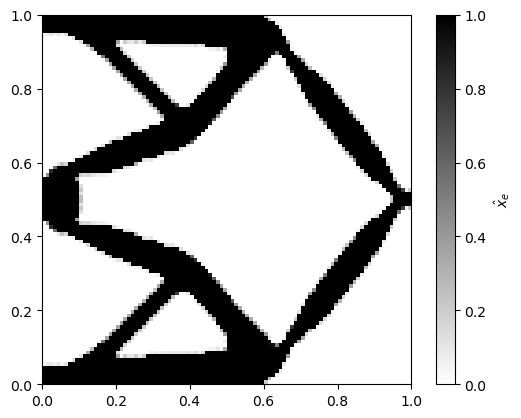

In [11]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
x_mid_reshaped = x_mid.reshape(sens.n2, sens.n1)
x_mid_full = np.vstack([x_mid_reshaped, np.flip(x_mid_reshaped, axis=0)])
y_min = 0.5 - sens.L2
y_max = 0.5 + sens.L2
plt.imshow(x_mid_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_min, y_max])
plt.colorbar(label='$\hat{x}_e$')
plt.gca().set_aspect('equal')

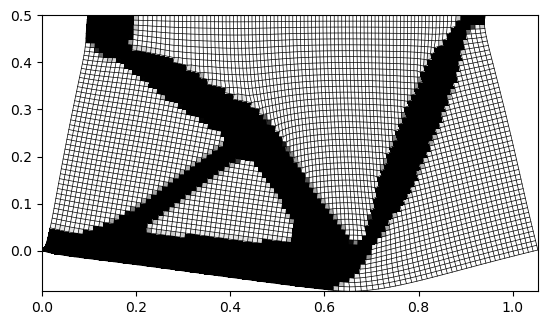

In [12]:
plot_deformation(sens, x_mid, sens.d, scale=0.1)

In [13]:
import numpy as np
from sens_elastic_compmech import Gripper as Sens
from optimizer import MMA as Optimizer
from filtering import Projection
ITR_MAX = 150
X_TOL = 1e-4
V_MAX = 0.3
sens = Sens()
x = np.full(sens.n1*sens.n2, V_MAX)
r = 2.0
eta0 = 0.25
eta_dil = eta0
eta_mid = 0.5
eta_ero = 1-eta0
beta0 = 1
opt = Optimizer(x, 1) 
def volume_constraint(x):
    g = np.array([x.sum()/len(x)-V_MAX])
    gradg = np.array(np.ones_like(x))[None,:]/len(x)
    return g, gradg
filters = [Projection(sens.n1, sens.n2, r, eta, beta0) for eta in [eta_dil, eta_mid, eta_ero]]
fil_dil, fil_mid, fil_ero = filters
for itr in range(ITR_MAX+1):
    x_dil, x_mid, x_ero = [fil.apply(itr, x) for fil in filters]
    f_dil, gradf_dil = sens.compute_obj_sens(x_dil)
    f_mid, gradf_mid = sens.compute_obj_sens(x_mid)
    f_ero, gradf_ero = sens.compute_obj_sens(x_ero)
    idx = np.argmax([f_dil, f_mid, f_ero])
    f, gradf_proj = ([f_dil, f_mid, f_ero][idx], [gradf_dil, gradf_mid, gradf_ero][idx])
    g, gradg_proj = volume_constraint(x_mid)
    gradf = fil_ero.modify_sensitivity_gradf(gradf_proj)
    gradg = fil_mid.modify_sensitivity_gradgi(gradg_proj)
    x_new = opt.run(itr, x, g, gradf, gradg)
    norm_inf_x = np.linalg.norm(x_new-x_mid, np.inf)
    m_nd = fil_mid.grayscale_indicator(x_mid)
    print(f"{itr} iters, f = {f:.2e}, g = {g[0]:.2e}, norm_inf_x = {norm_inf_x:.1e}, m_nd = {m_nd:.2f}")
    if norm_inf_x < X_TOL: print('Converged'); break
    x = x_new.copy()

0 iters, f = 1.18e-02, g = -2.44e-02, norm_inf_x = 7.5e-01, m_nd = 71.54
1 iters, f = 4.69e-04, g = -2.59e-02, norm_inf_x = 7.6e-01, m_nd = 70.56
2 iters, f = -3.85e-03, g = -2.34e-02, norm_inf_x = 7.1e-01, m_nd = 69.64
3 iters, f = -1.42e-02, g = -1.61e-02, norm_inf_x = 7.0e-01, m_nd = 69.36
4 iters, f = -3.40e-02, g = -7.40e-03, norm_inf_x = 7.4e-01, m_nd = 68.31
5 iters, f = -6.07e-02, g = 9.81e-04, norm_inf_x = 7.8e-01, m_nd = 66.29
6 iters, f = -8.91e-02, g = 2.78e-03, norm_inf_x = 8.3e-01, m_nd = 62.78
7 iters, f = -1.17e-01, g = 3.50e-03, norm_inf_x = 8.8e-01, m_nd = 59.90
8 iters, f = -1.46e-01, g = 3.84e-03, norm_inf_x = 9.3e-01, m_nd = 56.86
9 iters, f = -1.76e-01, g = 4.02e-03, norm_inf_x = 9.8e-01, m_nd = 53.44
10 iters, f = -2.05e-01, g = 4.09e-03, norm_inf_x = 1.0e+00, m_nd = 49.73
11 iters, f = -2.31e-01, g = 1.10e-03, norm_inf_x = 1.0e+00, m_nd = 45.95
12 iters, f = -2.56e-01, g = -6.88e-04, norm_inf_x = 1.0e+00, m_nd = 42.36
13 iters, f = -2.84e-01, g = -6.28e-04, norm

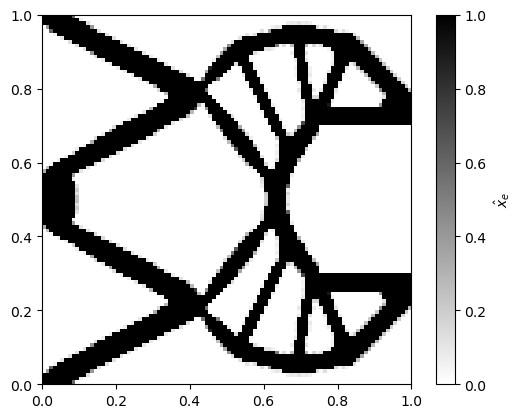

In [14]:
import matplotlib.pyplot as plt
x_p, y_p = np.linspace(0, sens.L1, sens.n1), np.linspace(0, sens.L2, sens.n2)
x_mid_reshaped = x_mid.reshape(sens.n2, sens.n1)
x_mid_full = np.vstack([x_mid_reshaped, np.flip(x_mid_reshaped, axis=0)])
y_min = 0.5 - sens.L2
y_max = 0.5 + sens.L2
plt.imshow(x_mid_full, origin='lower', cmap='binary', vmin=0, vmax=1, extent=[x_p.min(), x_p.max(), y_min, y_max])
plt.colorbar(label='$\hat{x}_e$')
plt.gca().set_aspect('equal')

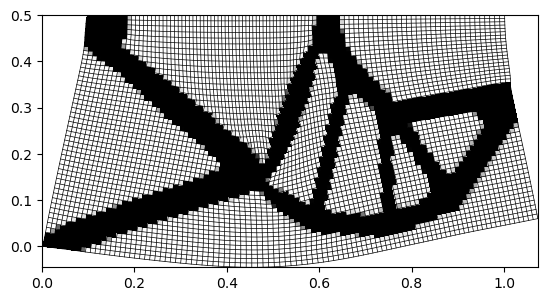

In [15]:
plot_deformation(sens, x_mid, sens.d, scale=0.1)